# Stock Data Preparation

This notebook prepares real historical stock market data for the
LSTM and GRU models.

## Steps

- Download historical stock data
- Inspect and clean the dataset
- Select the prediction feature
- Split the data chronologically
- Scale the data without leakage
- Create sliding-window sequences
- Create train, validation and test datasets
- Build a naive baseline
- Save the prepared data for later model training

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yfinance as yf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

In [2]:
TICKER = "AAPL"

START_DATE = "2015-01-01"
END_DATE = "2026-01-01"

LOOKBACK = 20

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15

BATCH_SIZE = 32

In [3]:
stock = yf.Ticker(TICKER)

df = stock.history(
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
)

df.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2015-01-02 00:00:00-05:00,27.847500,27.860001,26.837500,27.332500,24.171753,212818400,0.0,0.0
2015-01-05 00:00:00-05:00,27.072500,27.162500,26.352501,26.562500,23.490795,257142000,0.0,0.0
2015-01-06 00:00:00-05:00,26.635000,26.857500,26.157499,26.565001,23.493011,263188400,0.0,0.0
2015-01-07 00:00:00-05:00,26.799999,27.049999,26.674999,26.937500,23.822437,160423600,0.0,0.0
2015-01-08 00:00:00-05:00,27.307501,28.037500,27.174999,27.972500,24.737741,237458000,0.0,0.0


In [4]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_directory = project_root / "data"
data_directory.mkdir(exist_ok=True)

raw_data_path = (
    data_directory / f"{TICKER.lower()}_raw.csv"
)

df.to_csv(raw_data_path)

print("Saved to:", raw_data_path)

Saved to: /Users/omurravli/Desktop/pythorch_stock_predict/data/aapl_raw.csv


In [5]:
df = df.reset_index()

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
0,2015-01-02 00:00:00-05:00,27.847500,27.860001,26.837500,27.332500,24.171753,212818400,0.0,0.0
1,2015-01-05 00:00:00-05:00,27.072500,27.162500,26.352501,26.562500,23.490795,257142000,0.0,0.0
2,2015-01-06 00:00:00-05:00,26.635000,26.857500,26.157499,26.565001,23.493011,263188400,0.0,0.0
3,2015-01-07 00:00:00-05:00,26.799999,27.049999,26.674999,26.937500,23.822437,160423600,0.0,0.0
4,2015-01-08 00:00:00-05:00,27.307501,28.037500,27.174999,27.972500,24.737741,237458000,0.0,0.0


In [6]:
df = df.reset_index()

df.head()

,index,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
0,0,2015-01-02 00:00:00-05:00,27.847500,27.860001,26.837500,27.332500,24.171753,212818400,0.0,0.0
1,1,2015-01-05 00:00:00-05:00,27.072500,27.162500,26.352501,26.562500,23.490795,257142000,0.0,0.0
2,2,2015-01-06 00:00:00-05:00,26.635000,26.857500,26.157499,26.565001,23.493011,263188400,0.0,0.0
3,3,2015-01-07 00:00:00-05:00,26.799999,27.049999,26.674999,26.937500,23.822437,160423600,0.0,0.0
4,4,2015-01-08 00:00:00-05:00,27.307501,28.037500,27.174999,27.972500,24.737741,237458000,0.0,0.0


In [7]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)

df.columns.tolist()

['index',
 'date',
 'open',
 'high',
 'low',
 'close',
 'adj_close',
 'volume',
 'dividends',
 'stock_splits']

In [8]:
df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
    .reset_index(drop=True)
)

print("First date:", df["date"].iloc[0])
print("Last date:", df["date"].iloc[-1])

First date: 2015-01-02 00:00:00-05:00
Last date: 2025-12-31 00:00:00-05:00


In [9]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate dates:")
print(df["date"].duplicated().sum())

Missing values:
index           0
date            0
open            0
high            0
low             0
close           0
adj_close       0
volume          0
dividends       0
stock_splits    0
dtype: int64

Duplicate dates:
0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2766 entries, 0 to 2765
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype                          
---  ------        --------------  -----                          
 0   index         2766 non-null   int64                          
 1   date          2766 non-null   datetime64[s, America/New_York]
 2   open          2766 non-null   float64                        
 3   high          2766 non-null   float64                        
 4   low           2766 non-null   float64                        
 5   close         2766 non-null   float64                        
 6   adj_close     2766 non-null   float64                        
 7   volume        2766 non-null   int64                          
 8   dividends     2766 non-null   float64                        
 9   stock_splits  2766 non-null   float64                        
dtypes: datetime64[s, America/New_York](1), float64(7), int64(2)
memory usage: 216.2 KB


In [11]:
PRICE_COLUMN = "adj_close"

price_df = df[
    ["date", PRICE_COLUMN]
].copy()

price_df = price_df.rename(
    columns={
        PRICE_COLUMN: "price"
    }
)

price_df.head()

,date,price
0,2015-01-02 00:00:00-05:00,24.171753
1,2015-01-05 00:00:00-05:00,23.490795
2,2015-01-06 00:00:00-05:00,23.493011
3,2015-01-07 00:00:00-05:00,23.822437
4,2015-01-08 00:00:00-05:00,24.737741


In [12]:
missing_price_count = (
    price_df["price"]
    .isna()
    .sum()
)

print(
    "Missing price count:",
    missing_price_count,
)

Missing price count: 0


In [13]:
if missing_price_count > 0:
    raise ValueError(
        "Missing prices detected. "
        "Inspect the dataset before continuing."
    )

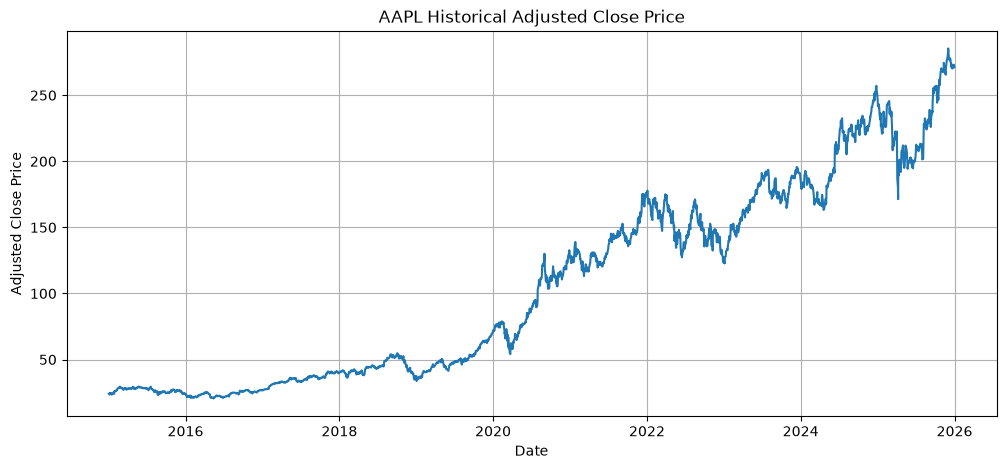

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    price_df["date"],
    price_df["price"],
)

plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.title(
    f"{TICKER} Historical Adjusted Close Price"
)

plt.grid(True)
plt.show()

In [15]:
number_of_rows = len(price_df)

train_end = int(
    number_of_rows * TRAIN_RATIO
)

validation_end = int(
    number_of_rows
    * (TRAIN_RATIO + VALIDATION_RATIO)
)

print("Total:", number_of_rows)
print("Train end:", train_end)
print("Validation end:", validation_end)

Total: 2766
Train end: 1936
Validation end: 2351


In [16]:
train_df = price_df.iloc[
    :train_end
].copy()

validation_df = price_df.iloc[
    train_end:validation_end
].copy()

test_df = price_df.iloc[
    validation_end:
].copy()

In [17]:
print(
    "Train:",
    train_df["date"].min(),
    "→",
    train_df["date"].max(),
)

print(
    "Validation:",
    validation_df["date"].min(),
    "→",
    validation_df["date"].max(),
)

print(
    "Test:",
    test_df["date"].min(),
    "→",
    test_df["date"].max(),
)

Train: 2015-01-02 00:00:00-05:00 → 2022-09-09 00:00:00-04:00
Validation: 2022-09-12 00:00:00-04:00 → 2024-05-06 00:00:00-04:00
Test: 2024-05-07 00:00:00-04:00 → 2025-12-31 00:00:00-05:00


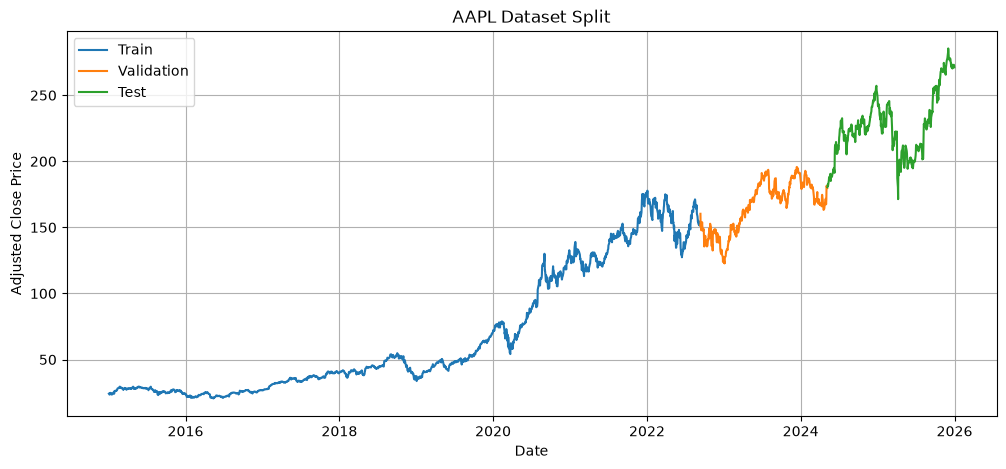

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    train_df["date"],
    train_df["price"],
    label="Train",
)

plt.plot(
    validation_df["date"],
    validation_df["price"],
    label="Validation",
)

plt.plot(
    test_df["date"],
    test_df["price"],
    label="Test",
)

plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.title(f"{TICKER} Dataset Split")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
scaler = MinMaxScaler(
    feature_range=(-1, 1)
)

scaler.fit(
    train_df[["price"]]
)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(-1, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[177.79]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[20.55]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[157.24]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['price']
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[-1.26]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,1936


In [20]:
scaled_prices = scaler.transform(
    price_df[["price"]]
)

price_df["scaled_price"] = (
    scaled_prices.ravel()
)

price_df.head()

,date,price,scaled_price
0,2015-01-02 00:00:00-05:00,24.171753,-0.953909
1,2015-01-05 00:00:00-05:00,23.490795,-0.962571
2,2015-01-06 00:00:00-05:00,23.493011,-0.962543
3,2015-01-07 00:00:00-05:00,23.822437,-0.958352
4,2015-01-08 00:00:00-05:00,24.737741,-0.946710


In [21]:
def create_sequences(
    values: np.ndarray,
    lookback: int,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    sequences = []
    targets = []
    target_indices = []

    for target_index in range(
        lookback,
        len(values),
    ):
        start_index = (
            target_index - lookback
        )

        sequence = values[
            start_index:target_index
        ]

        target = values[target_index]

        sequences.append(sequence)
        targets.append(target)
        target_indices.append(
            target_index
        )

    X = np.array(
        sequences,
        dtype=np.float32,
    ).reshape(
        -1,
        lookback,
        1,
    )

    y = np.array(
        targets,
        dtype=np.float32,
    ).reshape(
        -1,
        1,
    )

    target_indices = np.array(
        target_indices,
        dtype=np.int64,
    )

    return X, y, target_indices

In [22]:
values = price_df[
    "scaled_price"
].to_numpy(
    dtype=np.float32
)

X_all, y_all, target_indices = (
    create_sequences(
        values=values,
        lookback=LOOKBACK,
    )
)

print("X:", X_all.shape)
print("y:", y_all.shape)

X: (2746, 20, 1)
y: (2746, 1)


In [23]:
train_mask = (
    target_indices < train_end
)

validation_mask = (
    (target_indices >= train_end)
    & (target_indices < validation_end)
)

test_mask = (
    target_indices >= validation_end
)

In [25]:
X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_validation = X_all[
    validation_mask
]
y_validation = y_all[
    validation_mask
]

X_test = X_all[test_mask]
y_test = y_all[test_mask]

In [26]:
print(
    "Train:",
    X_train.shape,
    y_train.shape,
)

print(
    "Validation:",
    X_validation.shape,
    y_validation.shape,
)

print(
    "Test:",
    X_test.shape,
    y_test.shape,
)

Train: (1916, 20, 1) (1916, 1)
Validation: (415, 20, 1) (415, 1)
Test: (415, 20, 1) (415, 1)


In [27]:
train_target_dates = price_df.iloc[
    target_indices[train_mask]
]["date"]

validation_target_dates = price_df.iloc[
    target_indices[validation_mask]
]["date"]

test_target_dates = price_df.iloc[
    target_indices[test_mask]
]["date"]

print(
    "Last train target:",
    train_target_dates.iloc[-1],
)

print(
    "First validation target:",
    validation_target_dates.iloc[0],
)

print(
    "Last validation target:",
    validation_target_dates.iloc[-1],
)

print(
    "First test target:",
    test_target_dates.iloc[0],
)

Last train target: 2022-09-09 00:00:00-04:00
First validation target: 2022-09-12 00:00:00-04:00
Last validation target: 2024-05-06 00:00:00-04:00
First test target: 2024-05-07 00:00:00-04:00


In [28]:
X_train_tensor = torch.from_numpy(
    X_train
)
y_train_tensor = torch.from_numpy(
    y_train
)

X_validation_tensor = (
    torch.from_numpy(
        X_validation
    )
)
y_validation_tensor = (
    torch.from_numpy(
        y_validation
    )
)

X_test_tensor = torch.from_numpy(
    X_test
)
y_test_tensor = torch.from_numpy(
    y_test
)

In [29]:
print(
    X_train_tensor.shape,
    y_train_tensor.shape,
)

print(
    X_train_tensor.dtype,
    y_train_tensor.dtype,
)

torch.Size([1916, 20, 1]) torch.Size([1916, 1])
torch.float32 torch.float32


In [30]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

validation_dataset = TensorDataset(
    X_validation_tensor,
    y_validation_tensor,
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor,
)

In [31]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [32]:
batch_X, batch_y = next(
    iter(train_loader)
)

print(
    "X batch:",
    batch_X.shape,
)

print(
    "y batch:",
    batch_y.shape,
)

X batch: torch.Size([32, 20, 1])
y batch: torch.Size([32, 1])


In [33]:
baseline_scaled = X_test[
    :,
    -1,
    0,
].reshape(-1, 1)

In [34]:
baseline_predictions = (
    scaler.inverse_transform(
        baseline_scaled
    )
    .ravel()
)

actual_test_prices = (
    scaler.inverse_transform(
        y_test
    )
    .ravel()
)

In [35]:
baseline_mae = mean_absolute_error(
    actual_test_prices,
    baseline_predictions,
)

baseline_mse = mean_squared_error(
    actual_test_prices,
    baseline_predictions,
)

baseline_rmse = np.sqrt(
    baseline_mse
)

print(
    f"Baseline MAE : "
    f"{baseline_mae:.4f}"
)

print(
    f"Baseline MSE : "
    f"{baseline_mse:.4f}"
)

print(
    f"Baseline RMSE: "
    f"{baseline_rmse:.4f}"
)

Baseline MAE : 2.5887
Baseline MSE : 14.7321
Baseline RMSE: 3.8382


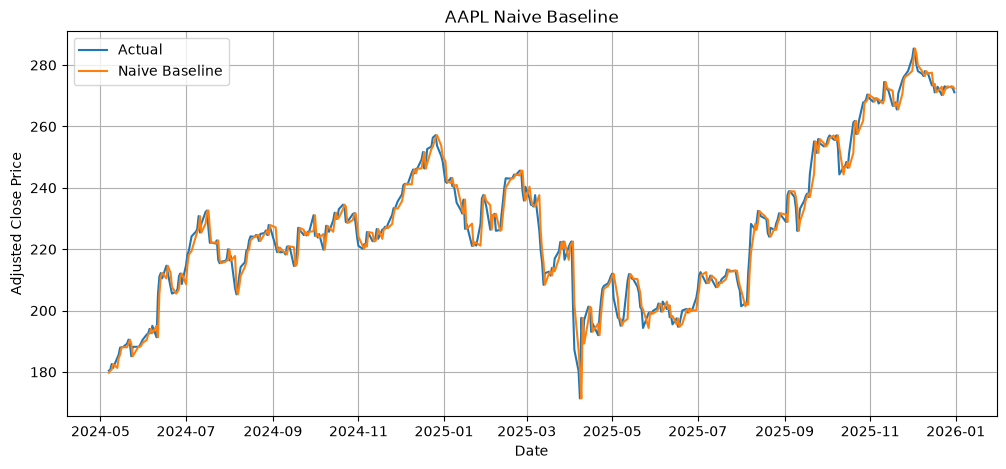

In [36]:
test_dates = (
    price_df.iloc[
        target_indices[test_mask]
    ]["date"]
    .to_numpy()
)

plt.figure(figsize=(12, 5))

plt.plot(
    test_dates,
    actual_test_prices,
    label="Actual",
)

plt.plot(
    test_dates,
    baseline_predictions,
    label="Naive Baseline",
)

plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")

plt.title(
    f"{TICKER} Naive Baseline"
)

plt.legend()
plt.grid(True)
plt.show()